In [1]:
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


link to dataset

In [10]:
import os

PROJECT_PATH = "/content/drive/MyDrive/cat_dog_project"

DATA_PATH = os.path.join(PROJECT_PATH, "data")
TRAIN_PATH = os.path.join(DATA_PATH, "train")
VAL_PATH = os.path.join(DATA_PATH, "val")
TEST_PATH = os.path.join(DATA_PATH, "test")


print(f"Train path: {TRAIN_PATH}")
print(f"Val path: {VAL_PATH}")
print(f"Test path: {TEST_PATH} ")

Train path: /content/drive/MyDrive/cat_dog_project/data/train
Val path: /content/drive/MyDrive/cat_dog_project/data/val
Test path: /content/drive/MyDrive/cat_dog_project/data/test 


import libraries , here I use Pytorch

In [3]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import time
from tqdm.auto import tqdm
import numpy as np

ResNet 18 model architecture

| Layer Name | Internal Block Structure | Input Dimension (Size In) | Output Dimension (Size Out) | Input Channels ($C_{\text{in}}$) | Output Channels ($C_{\text{out}}$) | Downsample in Shortcut? |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: |
| **Layer 0** (Stem) | Conv $7\times7$ (Stride 2) $\rightarrow$ MaxPool $3\times3$ (Stride 2) | $224 \times 224$ | $56 \times 56$ | 3 (RGB) | 64 | No (No shortcut) |
| **Layer 1** | $2 \times$ `BasicBlock` (Each with $2 \times$ Conv $3\times3$) | $56 \times 56$ | $56 \times 56$ | 64 | 64 | **No** (Identity Mapping) |
| **Layer 2** | $2 \times$ `BasicBlock` (Each with $2 \times$ Conv $3\times3$) | $56 \times 56$ | $28 \times 28$ | 64 | 128 | **Yes** (Killed via Conv $1\times1$ at Block 1) |
| **Layer 3** | $2 \times$ `BasicBlock` (Each with $2 \times$ Conv $3\times3$) | $28 \times 28$ | $14 \times 14$ | 128 | 256 | **Yes** (Killed via Conv $1\times1$ at Block 1) |
| **Layer 4** | $2 \times$ `BasicBlock` (Each with $2 \times$ Conv $3\times3$) | $14 \times 14$ | $7 \times 7$ | 256 | 512 | **Yes** (Killed via Conv $1\times1$ at Block 1) |
| **Output Block**| Global Average Pooling $\rightarrow$ Flatten $\rightarrow$ Fully Connected (FC) | $7 \times 7$ | Flattened Vector | 512 | `num_classes` 2 |


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels,kernel_size=3, stride=stride,padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels,kernel_size=3, stride=1,padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class ResNet18(nn.Module):
    def __init__(self, num_classes=2):
        super(ResNet18, self).__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(64, 2, stride=1)

        self.layer2 = self._make_layer(128, 2, stride=2)

        self.layer3 = self._make_layer(256, 2, stride=2)

        self.layer4 = self._make_layer(512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Sequential(nn.Dropout(0.3),nn.Linear(512 * BasicBlock.expansion, num_classes))



    def _make_layer(self, out_channels, num_blocks, stride):
        downsample = None

        if stride != 1 or self.in_channels != out_channels * BasicBlock.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * BasicBlock.expansion,kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * BasicBlock.expansion))

        layers = []
        layers.append(BasicBlock(self.in_channels, out_channels, stride, downsample))

        self.in_channels = out_channels * BasicBlock.expansion

        for _ in range(1, num_blocks):
            layers.append(BasicBlock(self.in_channels, out_channels, stride=1))

        return nn.Sequential(*layers)



    def forward(self, x):
        # stem
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # 4 stages
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # classifier
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x



class ImageClassifier(ResNet18):
    def __init__(self, num_classes=2):
        super().__init__(num_classes=num_classes)

- Train_step : load dataset and take it through the model for training(1 epoch)
- val_step: after a train_step take the val dataset through model to test( 1 epoch)
- Train: do train_step and val_step step by step for "epoch" times
  - Use early stopping (patience = 5)
  - Save the best model in training process
  - learning rate schedule (patience = 2)


In [5]:
def train_step(model: nn.Module,
               dataloader: DataLoader,
               loss_fn: nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device):
    model.train()
    train_loss, train_acc = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)
    return train_loss / len(dataloader), train_acc / len(dataloader)

def val_step(model: nn.Module,
             dataloader: DataLoader,
             loss_fn: nn.Module,
             device: torch.device):
    model.eval()
    val_loss, val_acc = 0, 0
    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            val_pred_logits = model(X)
            loss = loss_fn(val_pred_logits, y)
            val_loss += loss.item()
            val_pred_labels = val_pred_logits.argmax(dim=1)
            val_acc += ((val_pred_labels == y).sum().item() / len(val_pred_labels))
    return val_loss / len(dataloader), val_acc / len(dataloader)

def train(model: nn.Module,
          train_dataloader: DataLoader,
          val_dataloader: DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: nn.Module,
          epochs: int,
          device: torch.device,
          patience: int = 5):

    results = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_loss = float('inf')
    epochs_without_improvement = 0

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, device)
        val_loss, val_acc = val_step(model, val_dataloader, loss_fn, device)

        print(f"Epoch: {epoch+1} | train_loss: {train_loss:.4f} |train_acc: {train_acc:.4f}| val_loss: {val_loss:.4f} |val_acc: {val_acc:.4f}| learn_rate: {optimizer.param_groups[0]['lr']}")

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["val_loss"].append(val_loss)
        results["val_acc"].append(val_acc)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0
            torch.save(model.state_dict(), "best_model_temp.pth")
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stop")
                break

    model.load_state_dict(torch.load("best_model_temp.pth"))
    return results


Draw graph of training process

In [ ]:
def plot_loss_curves(results):
    loss = results['train_loss']
    val_loss = results['val_loss']
    accuracy = results['train_acc']
    val_accuracy = results['val_acc']

    epochs = range(len(results['train_loss']))

    plt.figure(figsize=(15, 7))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, val_loss, label='val_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, val_accuracy, label='val_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend()

    plt.show()

config , dataloader , augmentation
- Hyper paramater:
  - Epochs : 20
  - batch size : 20
  - learning rate : $3. 10^{-4}$
  - Loss function : cross entrophy
  

In [6]:

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

BATCH_SIZE = 64
NUM_EPOCHS = 20
IMAGE_SIZE = (224, 224)

model = ImageClassifier().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=3e-4)

#data augmentation for training set
train_transform = transforms.Compose([
    transforms.Resize(size=(256, 256)),
    transforms.RandomCrop(size=IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

#data augmentation for val set
val_transform = transforms.Compose([
    transforms.Resize(size=IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(root=TRAIN_PATH, transform=train_transform)
val_data = datasets.ImageFolder(root=VAL_PATH, transform=val_transform)

print(f"Train size: {len(train_data)}")
print(f"Val size: {len(val_data)}")
print(f"Classes: {train_data.classes}")

num_workers = 0 if os.name == 'nt' else os.cpu_count()

train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers)
val_dataloader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers)


Using device: cuda
Train size: 25071
Val size: 3123
Classes: ['cat', 'dog']


Init model and training

Start training
Batch size: 64, Epochs: 20


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.6102 |train_acc: 0.6767| val_loss: 0.5103 |val_acc: 0.7434| learn_rate: 0.0003
Epoch: 2 | train_loss: 0.4358 |train_acc: 0.7957| val_loss: 0.9759 |val_acc: 0.6875| learn_rate: 0.0003
Epoch: 3 | train_loss: 0.3277 |train_acc: 0.8572| val_loss: 0.3640 |val_acc: 0.8485| learn_rate: 0.0003
Epoch: 4 | train_loss: 0.2583 |train_acc: 0.8884| val_loss: 0.3875 |val_acc: 0.8338| learn_rate: 0.0003
Epoch: 5 | train_loss: 0.2054 |train_acc: 0.9146| val_loss: 0.1880 |val_acc: 0.9133| learn_rate: 0.0003
Epoch: 6 | train_loss: 0.1869 |train_acc: 0.9198| val_loss: 0.1784 |val_acc: 0.9234| learn_rate: 0.0003
Epoch: 7 | train_loss: 0.1680 |train_acc: 0.9300| val_loss: 0.1854 |val_acc: 0.9228| learn_rate: 0.0003
Epoch: 8 | train_loss: 0.1514 |train_acc: 0.9375| val_loss: 0.1664 |val_acc: 0.9356| learn_rate: 0.0003
Epoch: 9 | train_loss: 0.1400 |train_acc: 0.9440| val_loss: 0.1223 |val_acc: 0.9496| learn_rate: 0.0003
Epoch: 10 | train_loss: 0.1293 |train_acc: 0.9459| val_loss: 0.1

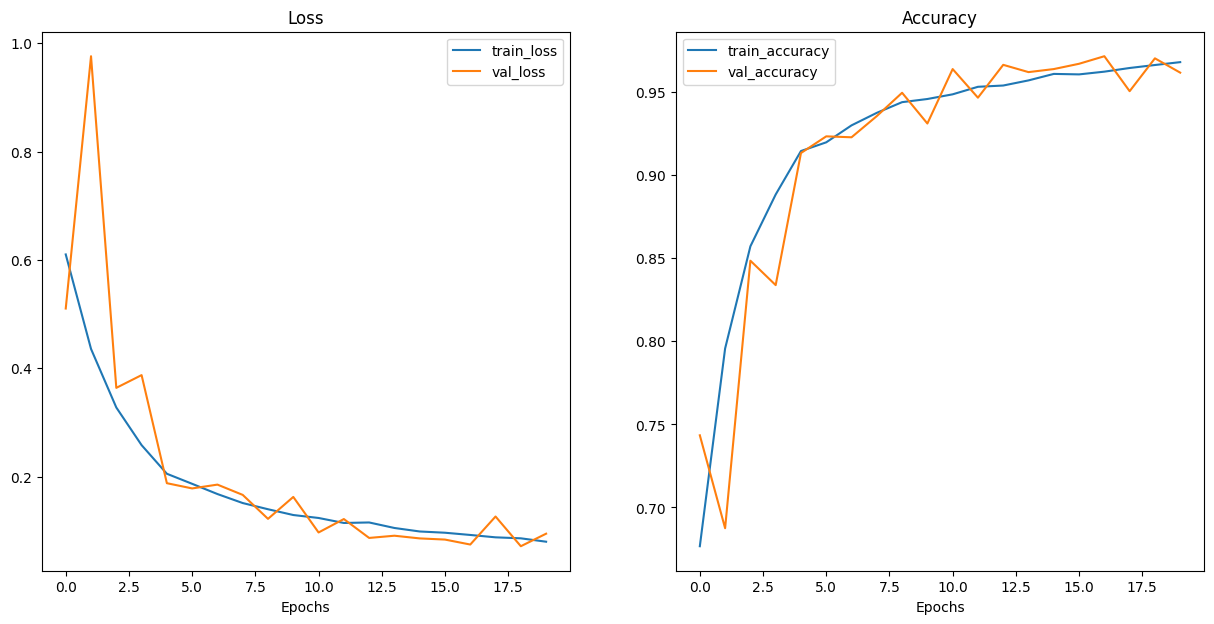

In [ ]:

print("Start training")
print(f"Batch size: {BATCH_SIZE}, Epochs: {NUM_EPOCHS}")
start_time = time.time()

model_results = train(model=model,
                      train_dataloader=train_dataloader,
                      val_dataloader=val_dataloader,
                      optimizer=optimizer,
                      loss_fn=loss_fn,
                      epochs=NUM_EPOCHS,
                      device=device)

end_time = time.time()
print(f"Training time: {(end_time - start_time):.3f}")

plot_loss_curves(model_results)

- The result model is from epoch 19 , which has the smallest val_loss

  - Epoch: 19 | train_loss: 0.0863 |train_acc: 0.9663| val_loss: 0.0717 |val_acc: 0.9703| learn_rate: 0.0003
- The loss, acc log and the graph show that the model seem to be ideal , even with only 25000 training images


Test model with 3500 images test set

In [7]:

test_transform = transforms.Compose([
    transforms.Resize(size=IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


test_data = datasets.ImageFolder(root=TEST_PATH, transform=test_transform)

print(f"Test size: {len(test_data)}")

test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers)


Test size: 3435


In [8]:
def test_step(model: nn.Module,
              dataloader: DataLoader,
              loss_fn: nn.Module,
              device: torch.device):
    model.eval()
    test_loss, test_acc = 0, 0
    all_preds = []
    all_targets = []

    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

            all_preds.append(test_pred_labels.cpu().numpy())
            all_targets.append(y.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    return test_loss / len(dataloader), test_acc / len(dataloader), all_targets, all_preds

Testing model
Test Loss: 0.0642
Test Accuracy: 0.9741
Precision: 0.9735
Recall: 0.9742
F1 Score: 0.9738


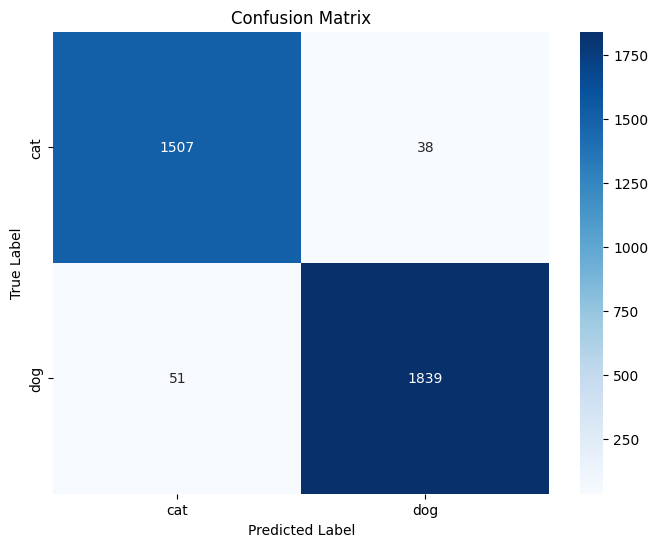

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix


print(f"Testing model")

test_loss, test_acc, all_targets, all_preds = test_step(model=model,
                                                         dataloader=test_dataloader,
                                                         loss_fn=loss_fn,
                                                         device=device)


precision = precision_score(all_targets, all_preds, average='macro')
recall = recall_score(all_targets, all_preds, average='macro')
f1 = f1_score(all_targets, all_preds, average='macro')

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Calculate and plot Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
class_names = test_data.classes

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()